<a href="https://colab.research.google.com/github/rathoretina07/Deep-learning-/blob/main/autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# --- Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Lambda
from tensorflow.keras import regularizers
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
%matplotlib inline

In [ ]:
print(X.shape, X_pred.shape)


(184426, 15) (36886, 15)


In [ ]:
# --- Load Data ---
df = pd.read_csv("allDataMean.csv")
target_col = "allDataMean6"
X = df.drop(columns=[target_col]).values.astype(np.float32)

In [ ]:
# --- Normalize ---
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# --- Train-Test Split ---
X_train, X_test = train_test_split(X_scaled, test_size=0.2, random_state=42)

In [ ]:
 #-- Plot Helpers ---
def plot_reconstruction(X, X_pred, title):
    plt.figure(figsize=(10, 5))
    plt.plot(X[:100, 0], label='Original', alpha=0.6)
    plt.plot(X_pred[:100, 0], label='Reconstructed', alpha=0.6)
    plt.title(title)
    plt.xlabel("Sample Index")
    plt.ylabel("Feature[0] Value")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
def plot_loss(history, title):
    plt.figure(figsize=(8, 4))
    plt.plot(history.history['loss'], label='Training Loss')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss (MSE)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Epoch 1/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0198 - val_loss: 3.8692e-04
Epoch 2/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 3.5184e-04 - val_loss: 2.6657e-04
Epoch 3/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 2.5227e-04 - val_loss: 2.1023e-04
Epoch 4/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 1.9527e-04 - val_loss: 1.5240e-04
Epoch 5/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 1.4437e-04 - val_loss: 1.2472e-04
Epoch 6/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 1.2244e-04 - val_loss: 1.1005e-04
Epoch 7/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 1.1020e-04 - val_loss: 1.0501e-04
Epoch 8/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 1.0352e-04 - val_loss: 1.0132e-04
Epoch 9/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 9.8452e-05 - val_loss: 9.5638e-05
Epoch 10/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 9.5795e-05 - val_loss: 9.5219e-05
Epoch 11/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 

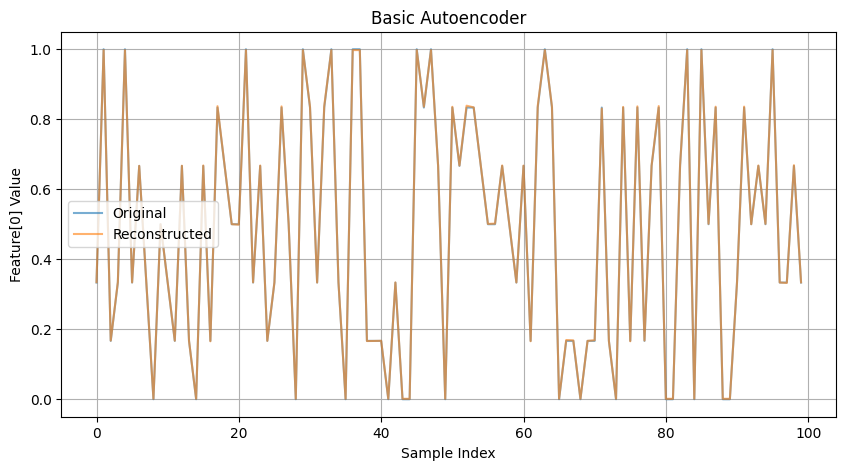

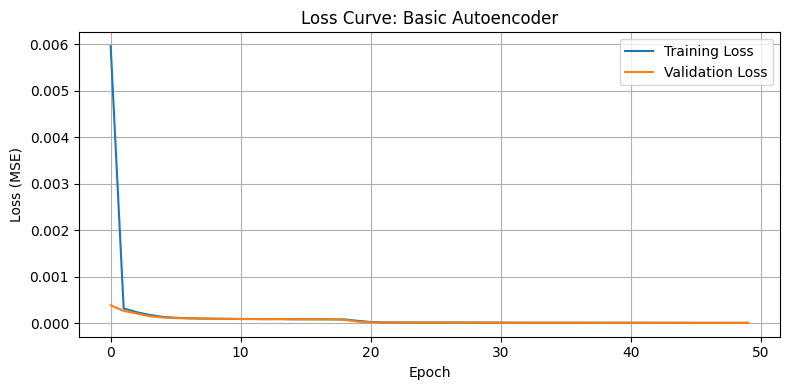

In [ ]:
# ========== 1. Basic Autoencoder ==========
input_dim = X.shape[1]
input_layer = Input(shape=(input_dim,))
encoded = Dense(64, activation='relu')(input_layer)
decoded = Dense(input_dim, activation='sigmoid')(encoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mse')

history_auto = autoencoder.fit(X_train, X_train, epochs=50, batch_size=64, shuffle=True, validation_split=0.1)
X_pred = autoencoder.predict(X_test)
plot_reconstruction(X_test, X_pred, "Basic Autoencoder")
plot_loss(history_auto, "Loss Curve: Basic Autoencoder")


In [ ]:
def evaluate_model(X_true, X_pred, model_name):
    mae = mean_absolute_error(X_true, X_pred)
    mse = mean_squared_error(X_true, X_pred)
    r2 = r2_score(X_true, X_pred)

    print(f"--- {model_name} ---")
    print(f"MAE: {mae:.6f}")
    print(f"MSE: {mse:.6f}")
    print(f"R² Score: {r2:.6f}")
    print()


In [ ]:
X_pred = autoencoder.predict(X_test)
evaluate_model(X_test, X_pred, "Basic Autoencoder")


1153/1153 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
--- Basic Autoencoder ---
MAE: 0.017580
MSE: 0.001099
R² Score: 0.905897



Epoch 1/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0089 - val_loss: 0.0052
Epoch 2/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0052 - val_loss: 0.0049
Epoch 3/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0050 - val_loss: 0.0048
Epoch 4/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0049 - val_loss: 0.0047
Epoch 5/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 0.0048 - val_loss: 0.0047
Epoch 6/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0047 - val_loss: 0.0046
Epoch 7/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0047 - val_loss: 0.0046
Epoch 8/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0046 - val_loss: 0.0045
Epoch 9/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0046 - val_loss: 0.0045
Epoch 10/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 0.0046 - val_loss: 0.0045
Epoch 11/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 0.0046 - val_loss: 0.0045
Epoch 12/50
2075/2075 ━━━━━━━━

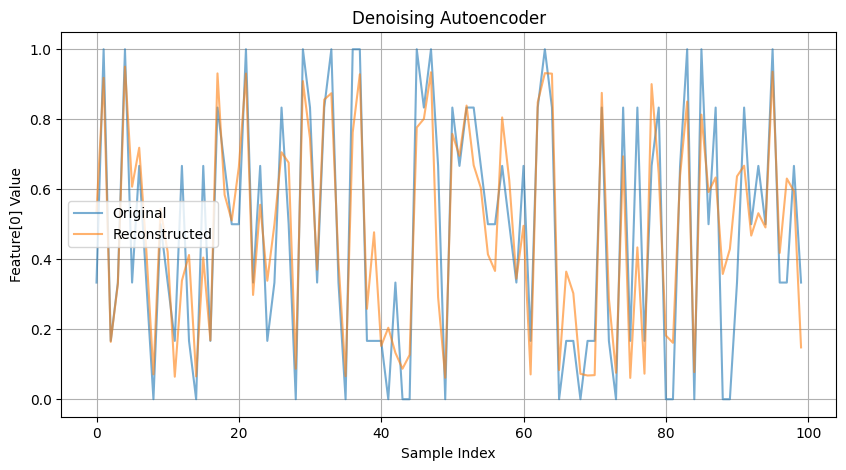

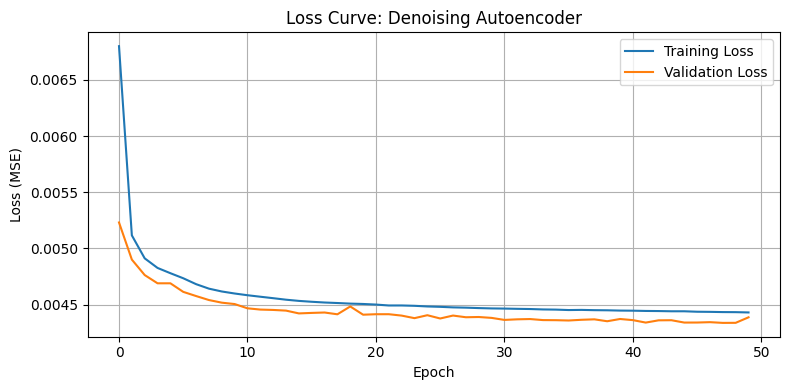

In [ ]:
# ========== 2. Denoising Autoencoder ==========
noise_factor = 0.2
X_train_noisy = X_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_train.shape)
X_test_noisy = X_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_test.shape)
X_train_noisy = np.clip(X_train_noisy, 0., 1.)
X_test_noisy = np.clip(X_test_noisy, 0., 1.)

dae = Model(inputs=input_layer, outputs=decoded)
dae.compile(optimizer='adam', loss='mse')
history_dae = dae.fit(X_train_noisy, X_train, epochs=50, batch_size=64, shuffle=True, validation_split=0.1)
X_pred_denoised = dae.predict(X_test_noisy)
plot_reconstruction(X_test, X_pred_denoised, "Denoising Autoencoder")
plot_loss(history_dae, "Loss Curve: Denoising Autoencoder")

In [ ]:
X_pred_denoised = dae.predict(X_test_noisy)
evaluate_model(X_test, X_pred_denoised, "Denoising Autoencoder")


1153/1153 ━━━━━━━━━━━━━━━━━━━━ 1s 656us/step
--- Denoising Autoencoder ---
MAE: 0.031070
MSE: 0.004420
R² Score: 0.830830



Epoch 1/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 0.0299 - val_loss: 0.0037
Epoch 2/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 0.0032 - val_loss: 0.0023
Epoch 3/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0021 - val_loss: 0.0017
Epoch 4/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0016 - val_loss: 0.0014
Epoch 5/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 6/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0011 - val_loss: 9.5746e-04
Epoch 7/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 9.2942e-04 - val_loss: 8.3673e-04
Epoch 8/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 8.1786e-04 - val_loss: 7.4746e-04
Epoch 9/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 7.3713e-04 - val_loss: 6.7316e-04
Epoch 10/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 6.6719e-04 - val_loss: 6.1559e-04
Epoch 11/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 6.0838e-04 - val_los

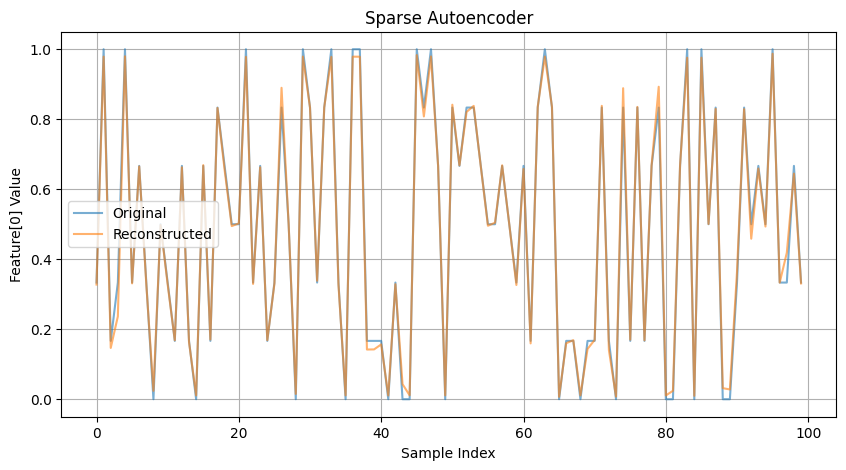

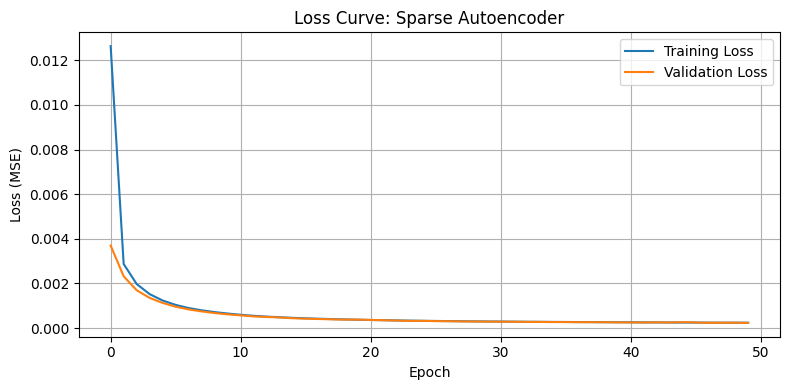

In [ ]:
# ========== 3. Sparse Autoencoder ==========
encoded_sparse = Dense(64, activation='relu', activity_regularizer=regularizers.l1(1e-5))(input_layer)
decoded_sparse = Dense(input_dim, activation='sigmoid')(encoded_sparse)

sparse_ae = Model(inputs=input_layer, outputs=decoded_sparse)
sparse_ae.compile(optimizer='adam', loss='mse')
history_sparse = sparse_ae.fit(X_train, X_train, epochs=50, batch_size=64, shuffle=True, validation_split=0.1)
X_pred_sparse = sparse_ae.predict(X_test)
plot_reconstruction(X_test, X_pred_sparse, "Sparse Autoencoder")
plot_loss(history_sparse, "Loss Curve: Sparse Autoencoder")

In [ ]:
X_pred_sparse = sparse_ae.predict(X_test)
evaluate_model(X_test, X_pred_sparse, "Sparse Autoencoder")


1153/1153 ━━━━━━━━━━━━━━━━━━━━ 1s 663us/step
--- Sparse Autoencoder ---
MAE: 0.005536
MSE: 0.000076
R² Score: 0.989293



Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


2075/2075 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 0.0739 - val_loss: 0.0595
Epoch 2/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 0.0595 - val_loss: 0.0595
Epoch 3/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0593 - val_loss: 0.0595
Epoch 4/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0594 - val_loss: 0.0594
Epoch 5/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0595 - val_loss: 0.0594
Epoch 6/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0596 - val_loss: 0.0594
Epoch 7/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0595 - val_loss: 0.0595
Epoch 8/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0596 - val_loss: 0.0594
Epoch 9/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 0.0595 - val_loss: 0.0594
Epoch 10/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0595 - val_loss: 0.0594
Epoch 11/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0596 - val_loss: 0.0594
Epoch 12/50
2075/2075 ━━━━━━━━━━━━━━━━━━━

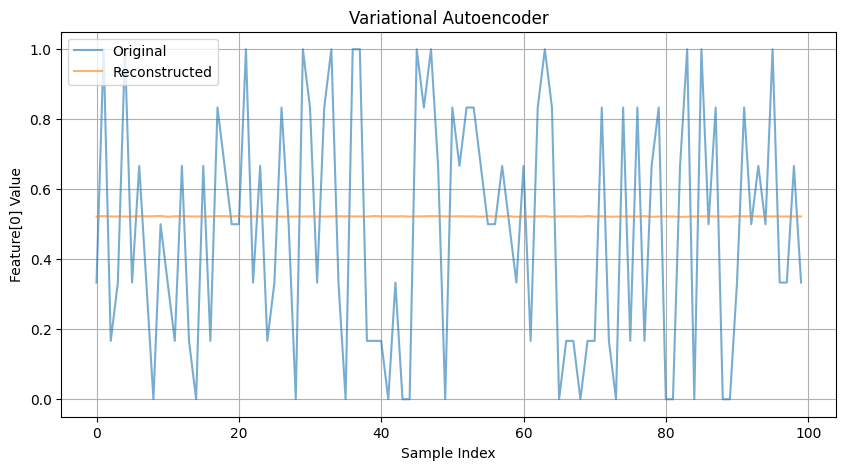

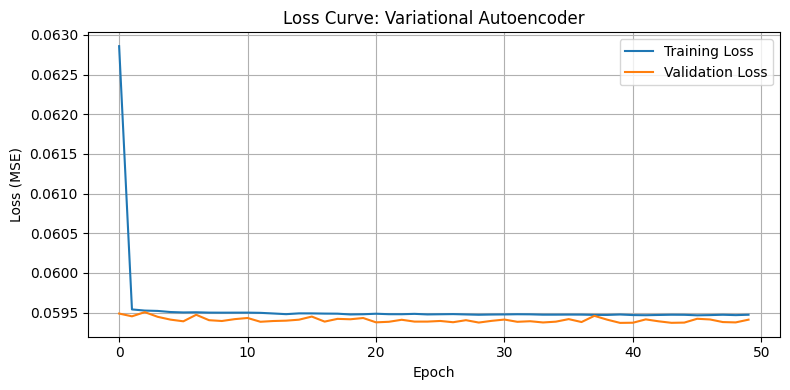

In [ ]:
# ========== 4. Variational Autoencoder (VAE, FIXED) ==========
from tensorflow.keras import layers

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

class VAE(tf.keras.Model):
    def __init__(self, original_dim, latent_dim=2):
        super(VAE, self).__init__()
        self.encoder = tf.keras.Sequential([
            layers.InputLayer(input_shape=(original_dim,)),
            layers.Dense(64, activation='relu'),
            layers.Dense(latent_dim + latent_dim)  # z_mean and z_log_var
        ])
        self.decoder = tf.keras.Sequential([
            layers.InputLayer(input_shape=(latent_dim,)),
            layers.Dense(64, activation='relu'),
            layers.Dense(original_dim, activation='sigmoid')
        ])
        self.sampler = Sampling()

    def call(self, x):
        z_params = self.encoder(x)
        z_mean, z_log_var = tf.split(z_params, num_or_size_splits=2, axis=1)
        z = self.sampler([z_mean, z_log_var])
        x_decoded = self.decoder(z)

        reconstruction_loss = tf.reduce_mean(tf.keras.losses.mse(x, x_decoded))
        kl_loss = -0.5 * tf.reduce_mean(tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1))
        self.add_loss(reconstruction_loss + kl_loss)

        return x_decoded

vae_model = VAE(original_dim=input_dim, latent_dim=2)
vae_model.compile(optimizer='adam')
vae_history = vae_model.fit(X_train, X_train, epochs=50, batch_size=64, validation_split=0.1)
X_pred_vae = vae_model.predict(X_test)
plot_reconstruction(X_test, X_pred_vae, "Variational Autoencoder")
plot_loss(vae_history, "Loss Curve: Variational Autoencoder")


In [ ]:
X_pred_vae = vae_model.predict(X_test)
evaluate_model(X_test, X_pred_vae, "Variational Autoencoder")


1153/1153 ━━━━━━━━━━━━━━━━━━━━ 1s 736us/step
--- Variational Autoencoder ---
MAE: 0.182295
MSE: 0.059582
R² Score: -0.001270

